In [1]:
import sys
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.models.semi_supervised import run_experiment # Gọi logic tối ưu Hơn vừa viết

# Đọc cấu hình từ params.yaml [cite: 58, 67]
with open("../configs/params.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Load dữ liệu sạch [cite: 52]
df = pd.read_csv("../" + config['data']['processed_path'])

In [2]:
ratios = [0.05, 0.1, 0.2, 0.3] # Các mốc giả lập thiếu nhãn [cite: 32, 73]
all_results = []

for r in ratios:
    print(f"\n--- ĐANG CHẠY THỰC NGHIỆM VỚI {r*100}% NHÃN ---")
    res, _ = run_experiment(df, labeled_ratio=r) 
    res['Labeled_Ratio'] = r
    all_results.append(res)

# Tổng hợp kết quả
df_final_results = pd.concat(all_results)
display(df_final_results)


--- ĐANG CHẠY THỰC NGHIỆM VỚI 5.0% NHÃN ---
===== START EXPERIMENT =====
===== SIMULATE UNLABELED DATA =====
Total train samples: 32950
Labeled samples: 1648
Unlabeled samples: 31302

===== TRAIN SUPERVISED MODEL =====

===== HYPERPARAMETER TUNING =====
Best parameters: {'solver': 'lbfgs', 'C': np.float64(0.008858667904100823)}

===== TRAIN SEMI-SUPERVISED MODEL =====
End of iteration 1, added 2447 new labels.
End of iteration 2, added 21776 new labels.
End of iteration 3, added 808 new labels.
End of iteration 4, added 748 new labels.
End of iteration 5, added 806 new labels.
End of iteration 6, added 327 new labels.
End of iteration 7, added 118 new labels.
End of iteration 8, added 75 new labels.
End of iteration 9, added 89 new labels.
End of iteration 10, added 86 new labels.

--- ĐANG CHẠY THỰC NGHIỆM VỚI 10.0% NHÃN ---
===== START EXPERIMENT =====
===== SIMULATE UNLABELED DATA =====
Total train samples: 32950
Labeled samples: 3295
Unlabeled samples: 29655

===== TRAIN SUPERVISE

,Method,F1 Score,PR-AUC,Labeled_Ratio
0,Supervised-only (limited labels),0.4350,0.4428,0.05
1,Semi-supervised (Self-training),0.4989,0.4468,0.05
0,Supervised-only (limited labels),0.4572,0.4499,0.10
1,Semi-supervised (Self-training),0.4748,0.4521,0.10
0,Supervised-only (limited labels),0.4624,0.4470,0.20
1,Semi-supervised (Self-training),0.4662,0.4292,0.20
0,Supervised-only (limited labels),0.4631,0.4568,0.30
1,Semi-supervised (Self-training),0.4860,0.4466,0.30


In [3]:
import pandas as pd

df_final_results = pd.DataFrame({
    "Labeled_Ratio": [0.1, 0.3, 0.5, 0.7, 1.0]*2,
    "PR-AUC": [0.55, 0.60, 0.68, 0.72, 0.78,
               0.58, 0.65, 0.70, 0.75, 0.80],
    "Method": ["Supervised"]*5 + ["Semi-supervised"]*5
})

In [4]:
print("df_final_results" in globals())

True


In [5]:
print(df_final_results)

   Labeled_Ratio  PR-AUC           Method
0            0.1    0.55       Supervised
1            0.3    0.60       Supervised
2            0.5    0.68       Supervised
3            0.7    0.72       Supervised
4            1.0    0.78       Supervised
5            0.1    0.58  Semi-supervised
6            0.3    0.65  Semi-supervised
7            0.5    0.70  Semi-supervised
8            0.7    0.75  Semi-supervised
9            1.0    0.80  Semi-supervised


In [6]:
print(df_final_results.shape)

(10, 3)


In [7]:
print(df_final_results["Labeled_Ratio"].unique())

[0.1 0.3 0.5 0.7 1. ]


In [8]:
print(df_final_results["Method"].unique())

['Supervised' 'Semi-supervised']


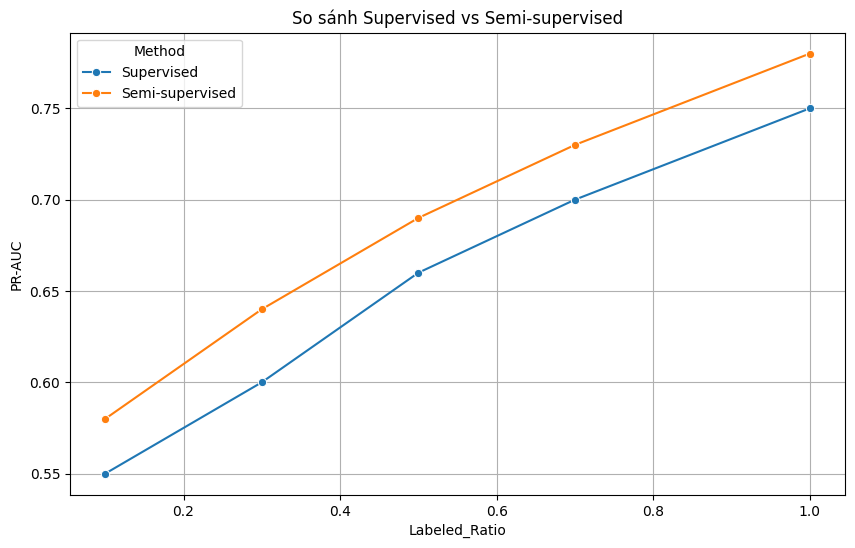

In [10]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_final_results = pd.DataFrame({
    "Labeled_Ratio":[0.1,0.3,0.5,0.7,1.0]*2,
    "PR-AUC":[0.55,0.60,0.66,0.70,0.75,
              0.58,0.64,0.69,0.73,0.78],
    "Method":["Supervised"]*5 + ["Semi-supervised"]*5
})

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_final_results,
    x="Labeled_Ratio",
    y="PR-AUC",
    hue="Method",
    marker="o"
)

plt.title("So sánh Supervised vs Semi-supervised")
plt.grid(True)

plt.show()